In [8]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [7]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
from xgboost import XGBRegressor

In [10]:
# Load the dataset

df = pd.read_csv("House_Price_Prediction_Dataset_1000.csv")

# Display the first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,3219,1,1,3,2007,Urban,Excellent,Yes,1299445
1,2,1019,6,5,1,2017,Urban,Excellent,Yes,1141508
2,3,1552,5,5,1,2002,Rural,Average,No,798886
3,4,2439,5,3,1,2000,Rural,Good,No,989790
4,5,1236,2,2,1,1995,Suburban,Excellent,No,712461


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         1000 non-null   int64
 1   Area       1000 non-null   int64
 2   Bedrooms   1000 non-null   int64
 3   Bathrooms  1000 non-null   int64
 4   Floors     1000 non-null   int64
 5   YearBuilt  1000 non-null   int64
 6   Location   1000 non-null   str  
 7   Condition  1000 non-null   str  
 8   Garage     1000 non-null   str  
 9   Price      1000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 93.1 KB


In [11]:
# Shape of the dataset
df.shape

(1000, 10)

In [12]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

In [13]:
# Missing values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [14]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [15]:
# Describe the dataset
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,2562.076000,3.599000,2.388000,2.004000,2006.992000,1.105132e+06
std,288.819436,1137.740053,1.695604,1.271642,0.827447,9.894738,2.970589e+05
min,1.000000,600.000000,1.000000,1.000000,1.000000,1990.000000,3.215660e+05
25%,250.750000,1552.750000,2.000000,1.000000,1.000000,1998.750000,8.729618e+05
50%,500.500000,2577.000000,4.000000,2.000000,2.000000,2007.000000,1.096532e+06
75%,750.250000,3559.000000,5.000000,3.000000,3.000000,2015.000000,1.337189e+06
max,1000.000000,4499.000000,6.000000,5.000000,3.000000,2024.000000,1.850060e+06


In [16]:
# Display a random sample of 5 rows
df.sample(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
612,613,2083,5,1,3,2004,Suburban,Good,Yes,1070816
198,199,1023,3,1,3,2001,Urban,Excellent,No,822857
738,739,1297,1,1,1,2007,Urban,Good,Yes,722704
167,168,3193,5,5,3,2010,Suburban,Average,No,1347194
182,183,1718,2,2,1,2012,Suburban,Excellent,No,875407


# Data Preprocessing

In [17]:
# Remove unnecessary column

df = df.drop("Id", axis=1)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,3219,1,1,3,2007,Urban,Excellent,Yes,1299445
1,1019,6,5,1,2017,Urban,Excellent,Yes,1141508
2,1552,5,5,1,2002,Rural,Average,No,798886
3,2439,5,3,1,2000,Rural,Good,No,989790
4,1236,2,2,1,1995,Suburban,Excellent,No,712461


In [18]:
# Convert categorical columns into numerical values

df = pd.get_dummies(
    df,
    columns=["Location", "Condition", "Garage"],
    drop_first=True
)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Good,Garage_Yes
0,3219,1,1,3,2007,1299445,False,True,True,False,True
1,1019,6,5,1,2017,1141508,False,True,True,False,True
2,1552,5,5,1,2002,798886,False,False,False,False,False
3,2439,5,3,1,2000,989790,False,False,False,True,False
4,1236,2,2,1,1995,712461,True,False,True,False,False


# Feature Selection and Target Variable

In [19]:
# Separate Features (X) and Target (y)

X = df.drop("Price", axis=1)
y = df["Price"]

In [20]:
X.head()    #no price will be shown

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Good,Garage_Yes
0,3219,1,1,3,2007,False,True,True,False,True
1,1019,6,5,1,2017,False,True,True,False,True
2,1552,5,5,1,2002,False,False,False,False,False
3,2439,5,3,1,2000,False,False,False,True,False
4,1236,2,2,1,1995,True,False,True,False,False


In [21]:
y.head()

0    1299445
1    1141508
2     798886
3     989790
4     712461
Name: Price, dtype: int64

In [22]:
# Split training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [29]:
models = {

    # Baseline Models
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "KNN": KNeighborsRegressor(),

    # Ensemble Models
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    )
}

In [33]:
results = []

trained_models = {}

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store Results
    results.append([name, r2, mae, rmse])

In [34]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.996781,13872.923379,16239.339074
4,Gradient Boosting,0.987155,26242.923794,32440.630394
5,XGBoost,0.971734,38431.468750,48122.957183
3,Random Forest,0.945676,53067.479267,66713.291559
1,Decision Tree,0.856792,85992.575000,108317.732331
2,KNN,0.732551,120980.852000,148025.701465


## Model Comparison

The project compares both traditional machine learning models and ensemble learning models.

### Baseline Models
- Linear Regression
- Decision Tree
- K-Nearest Neighbors (KNN)

### Ensemble Learning Models
- Random Forest (Bagging)
- Gradient Boosting (Boosting)
- Extreme Gradient Boosting - XGBoost (Boosting)

Traditional models are evaluated as baseline models, while the final prediction model will be selected from the ensemble learning algorithms, as the objective of this project is to study Ensemble Learning techniques for house price prediction.

In [35]:
ensemble_results = results_df[
    results_df["Model"].isin([
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ])
]

ensemble_results

,Model,R2 Score,MAE,RMSE
4,Gradient Boosting,0.987155,26242.923794,32440.630394
5,XGBoost,0.971734,38431.468750,48122.957183
3,Random Forest,0.945676,53067.479267,66713.291559


## Final Model Selection

The project focuses on Ensemble Learning. Therefore, the final model is selected only from the ensemble learning algorithms based on evaluation metrics.

In [53]:
best_model_name = ensemble_results.iloc[0]["Model"]

print("Best Ensemble Model:", best_model_name)

model = trained_models[best_model_name]

Best Ensemble Model: Gradient Boosting


# Model Evaluation

In [37]:
# Predict house prices for the test data

y_pred = model.predict(X_test)

y_pred[:5]

array([1075921.76219714, 1138680.33370326, 1522002.55779789,
       1612398.00849355,  751800.67075221])

In [38]:
print("Final Model Used:", best_model_name)
print("-" * 40)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2:.6f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

Final Model Used: Gradient Boosting
----------------------------------------
R² Score : 0.987155
MAE      : 26242.92
RMSE     : 32440.63


# Feature Importance

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Area,0.755819
1,Bedrooms,0.123702
6,Location_Urban,0.038863
7,Condition_Excellent,0.019614
2,Bathrooms,0.018483
4,YearBuilt,0.016863
5,Location_Suburban,0.010573
9,Garage_Yes,0.006927
8,Condition_Good,0.005753
3,Floors,0.003403


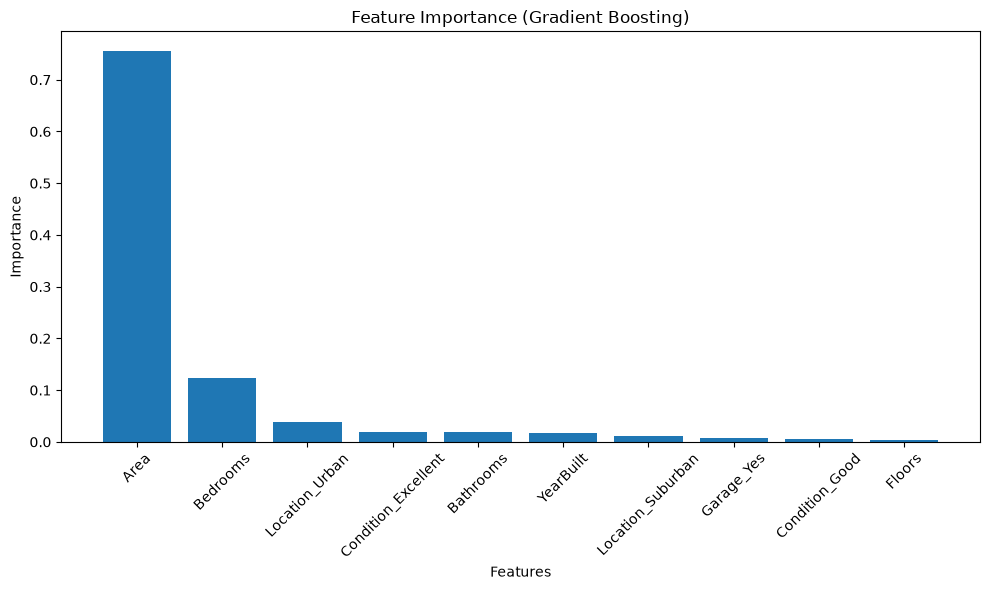

In [41]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title(f"Feature Importance ({best_model_name})")

plt.tight_layout()

plt.show()

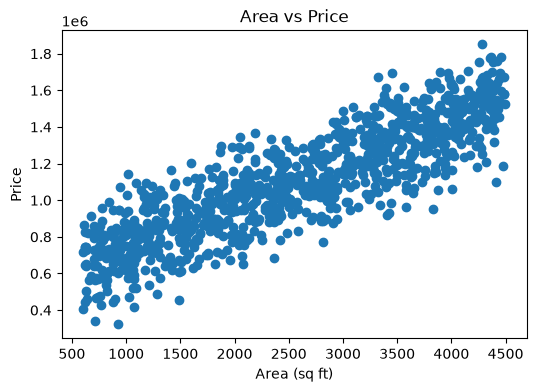

In [42]:
#Area vs Price Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df["Area"], df["Price"])
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

# Actual vs Predicted Prices

In [43]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1054231,1.075922e+06
1,1082901,1.138680e+06
2,1548196,1.522003e+06
3,1659220,1.612398e+06
4,680819,7.518007e+05
5,719073,7.369620e+05
6,1532457,1.520560e+06
7,724128,7.531587e+05
8,1363003,1.338490e+06
9,1200943,1.165512e+06


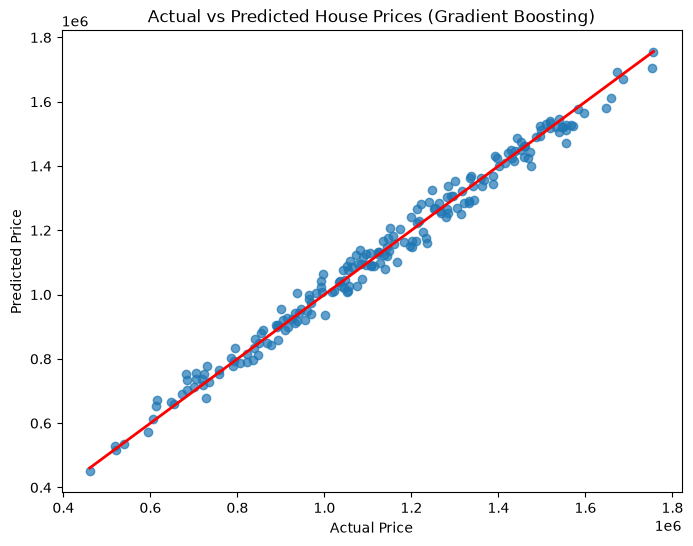

In [45]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")

plt.show()

# Prediction Error

In [46]:
errors = y_test - y_pred

errors.head()

521   -21690.762197
737   -55779.333703
740    26193.442202
660    46821.991506
411   -70981.670752
Name: Price, dtype: float64

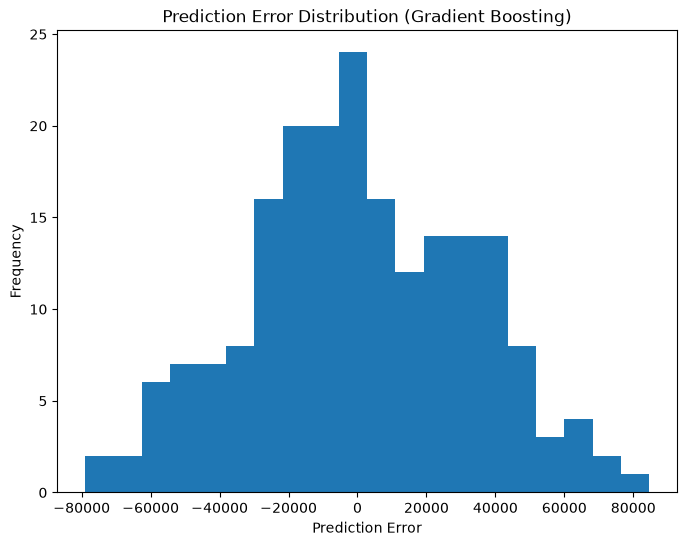

In [48]:
# Plot Error Distribution

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution ({best_model_name})")

plt.show()

In [54]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [55]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


# Predict House Price Using User Input

In [49]:
# Create sample input

sample_house = pd.DataFrame({
    "Area": [2500],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Floors": [2],
    "YearBuilt": [2018],

    "Location_Suburban": [0],
    "Location_Urban": [1],

    "Condition_Excellent": [1],
    "Condition_Good": [0],

    "Garage_Yes": [1]
})

In [50]:
# Predict the house price

predicted_price = model.predict(sample_house)

print(f"\nModel Used: {best_model_name}")
print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")


Model Used: Gradient Boosting
Predicted House Price: ₹1,319,085.96


In [51]:
# User Input
area = float(input("Enter Area (sq ft): "))
bedrooms = int(input("Enter Number of Bedrooms: "))
bathrooms = int(input("Enter Number of Bathrooms: "))
floors = int(input("Enter Number of Floors: "))
year = int(input("Enter Year Built: "))

location = input("Enter Location (Urban/Suburban/Rural): ").strip().title()
condition = input("Enter Condition (Excellent/Good/Average): ").strip().title()
garage = input("Garage Available? (Yes/No): ").strip().title()

# Convert User Input to One-Hot Encoding

sample_house = pd.DataFrame({
    "Area": [area],
    "Bedrooms": [bedrooms],
    "Bathrooms": [bathrooms],
    "Floors": [floors],
    "YearBuilt": [year],

    "Location_Suburban": [1 if location == "Suburban" else 0],
    "Location_Urban": [1 if location == "Urban" else 0],

    "Condition_Excellent": [1 if condition == "Excellent" else 0],
    "Condition_Good": [1 if condition == "Good" else 0],

    "Garage_Yes": [1 if garage == "Yes" else 0]
})

# Predict House Price

predicted_price = model.predict(sample_house)

print("\nPredicted House Price: ₹{:,.2f}".format(predicted_price[0]))


Predicted House Price: ₹1,458,336.88


# Conclusion

This project compares both traditional machine learning and ensemble learning algorithms for house price prediction.

Traditional models (Linear Regression, Decision Tree, and KNN) were used as baseline models.

Among the ensemble learning algorithms, Gradient Boosting achieved the best performance and was selected as the final prediction model.

The model was evaluated using:
- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Feature Importance
- Actual vs Predicted Price Analysis
- Prediction Error Distribution

Finally, the trained model can predict house prices using custom user input.